# Laboratorio 6 - K Nearest Neighbors (KNN)

**CC3074 – Minería de Datos | UVG | Semestre I – 2026**

SmartStay Advisors: Predicción y clasificación de precios de Airbnb usando KNN.

In [1]:
%pip install rdata --quiet --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import rdata

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_score, recall_score, f1_score,
)

warnings.filterwarnings("ignore")
np.random.seed(42)

%matplotlib inline

## Carga y preparación de datos

Se replica exactamente el mismo pipeline de limpieza y preparación del lab 5 para garantizar que los conjuntos de entrenamiento y prueba sean idénticos y los modelos sean comparables.

In [3]:
parsed = rdata.parser.parse_file("listings.RData")
converted = rdata.conversion.convert(parsed)
df = list(converted.values())[0]

# Convertir nombres de columna y columnas string[python] a tipos nativos
# (rdata usa np.str_ y StringDtype que sklearn no reconoce)
df.columns = [str(c) for c in df.columns]
for col in df.columns:
    if pd.api.types.is_string_dtype(df[col]):
        df[col] = df[col].astype(object)

print(f"Dataset original: {df.shape[0]:,} filas, {df.shape[1]} columnas")
df.head()

Dataset original: 171,748 filas, 80 columnas


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
1,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,<NA>,f,1,1,0,0,3.52,"Austin, Texas"
2,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,<NA>,t,1,1,0,0,1.98,"Austin, Texas"
3,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,<NA>,f,1,1,0,0,0.28,"Austin, Texas"
4,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,<NA>,f,2,2,0,0,0.11,"Austin, Texas"
5,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,<NA>,f,1,1,0,0,0.30,"Austin, Texas"


In [4]:
filas_antes = len(df)

df["price_num"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
df["price_num"] = pd.to_numeric(df["price_num"], errors="coerce")

df = df[df["price_num"].notna() & (df["price_num"] > 0)].copy()
print(f"Filas antes: {filas_antes:,} → después de limpiar precio: {len(df):,}")
print(df["price_num"].describe().round(2))

Filas antes: 171,748 → después de limpiar precio: 76,246
count    76246.00
mean       750.51
std       4250.61
min          8.00
25%        120.00
50%        193.00
75%        326.00
max      50123.00
Name: price_num, dtype: float64


In [5]:
df_model = df.copy()

cols_drop = [
    "id", "listing_url", "scrape_id", "last_scraped", "source",
    "name", "description", "neighborhood_overview", "picture_url",
    "host_url", "host_name", "host_since", "host_location", "host_about",
    "host_thumbnail_url", "host_picture_url", "host_verifications",
    "neighbourhood", "calendar_updated", "calendar_last_scraped",
    "first_review", "last_review", "license", "bathrooms_text", "amenities",
]
cols_drop = [col for col in cols_drop if col in df_model.columns]
df_model = df_model.drop(columns=cols_drop).copy()

# Eliminar columnas con más del 50% de nulos
high_null = df_model.isnull().mean()
cols_high_null = high_null[high_null > 0.50].index.tolist()
df_model = df_model.drop(columns=cols_high_null).copy()

# Convertir booleanos t/f
bool_cols = [
    "host_is_superhost", "host_has_profile_pic",
    "host_identity_verified", "has_availability", "instant_bookable",
]
for col in bool_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map({"t": 1, "f": 0}).astype("float")

# Convertir porcentajes
for col in ["host_response_rate", "host_acceptance_rate"]:
    if col in df_model.columns:
        df_model[col] = (
            df_model[col].astype(str)
            .str.replace("%", "", regex=False).str.strip()
        )
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce") / 100

# Forzar numéricas
force_numeric = [
    "bedrooms", "beds", "bathrooms",
    "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights",
    "host_listings_count", "host_total_listings_count",
]
for col in force_numeric:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

numeric_columns_all = df_model.select_dtypes(include="number").columns.tolist()
categorical_columns_all = df_model.select_dtypes(include="object").columns.tolist()

df_model[numeric_columns_all] = df_model[numeric_columns_all].apply(
    pd.to_numeric, errors="coerce",
)
df_model[numeric_columns_all] = df_model[numeric_columns_all].fillna(
    df_model[numeric_columns_all].median()
)

for col in categorical_columns_all:
    df_model[col] = df_model[col].where(df_model[col].notna(), "desconocido")
    df_model[col] = df_model[col].astype(str).replace("N/A", "desconocido")

# Excluir variables con fuga de información
excluded_features = [
    col for col in ["host_id", "estimated_occupancy_l365d", "estimated_revenue_l365d"]
    if col in df_model.columns
]

X_model = df_model.drop(
    columns=["price", "price_num"] + excluded_features, errors="ignore",
)
y_price = df_model["price_num"].copy()

numerical_preview = selector(dtype_exclude=object)(X_model)
categorical_preview = selector(dtype_include=object)(X_model)

print(f"Filas disponibles para modelar: {len(df_model):,}")
print(f"Variables predictoras: {X_model.shape[1]}")
print(f"  Numéricas: {len(numerical_preview)}")
print(f"  Categóricas: {len(categorical_preview)}")

Filas disponibles para modelar: 76,246
Variables predictoras: 51
  Numéricas: 44
  Categóricas: 7


In [6]:
X_train, X_test, y_train_price, y_test_price = train_test_split(
    X_model,
    y_price,
    test_size=0.30,
    train_size=0.70,
    random_state=42,
)

numerical_columns = selector(dtype_exclude=object)(X_train)
categorical_columns = selector(dtype_include=object)(X_train)

print("=== Criterio de división ===")
print("Proporción: 70% entrenamiento / 30% prueba")
print(f"Train: {len(X_train):,} filas")
print(f"Test:  {len(X_test):,} filas")
print(f"Columnas numéricas: {len(numerical_columns)}")
print(f"Columnas categóricas: {len(categorical_columns)}")

pd.DataFrame({"train": y_train_price.describe(), "test": y_test_price.describe()}).round(2)

=== Criterio de división ===
Proporción: 70% entrenamiento / 30% prueba
Train: 53,372 filas
Test:  22,874 filas
Columnas numéricas: 44
Columnas categóricas: 7


,train,test
count,53372.00,22874.00
mean,747.00,758.69
std,4245.56,4262.44
min,8.00,9.00
25%,120.00,121.00
50%,192.00,194.00
75%,325.00,330.00
max,50123.00,50020.00


## Inciso 1 – Modelo de regresión con KNN

Construimos un modelo de regresión KNN para predecir el precio de las propiedades. Se usa un pipeline con:
-  +  para las variables categóricas
-  +  para las numéricas (el escalado es fundamental en KNN ya que se basa en distancias)

Primero buscamos el mejor valor de K probando varios candidatos con validación cruzada, y luego entrenamos el modelo final.

In [7]:
# Preprocessor para KNN: escalar numéricas + OHE categóricas
knn_preprocessor = ColumnTransformer(
    [
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]),
            categorical_columns,
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numerical_columns,
        ),
    ]
)

# Probar varios valores de K
k_values = [3, 5, 7, 9, 11, 15, 21, 31]
results_k = []

for k in k_values:
    pipeline_k = Pipeline([
        ("preprocessor", knn_preprocessor),
        ("knn", KNeighborsRegressor(n_neighbors=k, metric="minkowski", p=2)),
    ])
    # Validación cruzada con 5 folds
    cv_scores = cross_val_score(
        pipeline_k, X_train, y_train_price,
        cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1,
    )
    results_k.append({
        "K": k,
        "RMSE_CV_mean": -cv_scores.mean(),
        "RMSE_CV_std": cv_scores.std(),
    })
    print(f"K={k:3d}  |  RMSE CV: {-cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

df_k = pd.DataFrame(results_k)
best_k = int(df_k.loc[df_k["RMSE_CV_mean"].idxmin(), "K"])
print(f"Mejor K según validación cruzada: {best_k}")

K=  3  |  RMSE CV: 1831.42 ± 121.52
K=  5  |  RMSE CV: 1887.36 ± 121.70
K=  7  |  RMSE CV: 1947.44 ± 89.37
K=  9  |  RMSE CV: 2023.66 ± 51.73
K= 11  |  RMSE CV: 2107.06 ± 57.33
K= 15  |  RMSE CV: 2201.57 ± 86.11
K= 21  |  RMSE CV: 2334.12 ± 102.64
K= 31  |  RMSE CV: 2466.57 ± 108.66
Mejor K según validación cruzada: 3


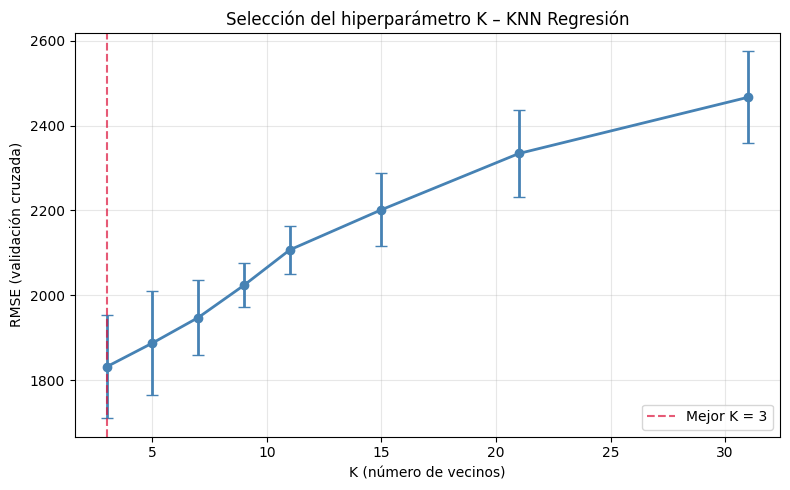

In [8]:
# Gráfica de selección de K
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(df_k["K"], df_k["RMSE_CV_mean"], yerr=df_k["RMSE_CV_std"],
            marker="o", capsize=4, color="steelblue", linewidth=2)
ax.axvline(best_k, color="crimson", linestyle="--", alpha=0.7, label=f"Mejor K = {best_k}")
ax.set_xlabel("K (número de vecinos)")
ax.set_ylabel("RMSE (validación cruzada)")
ax.set_title("Selección del hiperparámetro K – KNN Regresión")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Entrenar modelo final con el mejor K
knn_reg_pipeline = Pipeline([
    ("preprocessor", knn_preprocessor),
    ("knn", KNeighborsRegressor(n_neighbors=best_k, metric="minkowski", p=2)),
])

start = time.time()
knn_reg_pipeline.fit(X_train, y_train_price)
knn_train_time = time.time() - start

start = time.time()
y_pred_knn = knn_reg_pipeline.predict(X_test)
knn_pred_time = time.time() - start

print(f"Modelo KNN entrenado (K={best_k})")
print(f"Tiempo de entrenamiento: {knn_train_time:.2f}s")
print(f"Tiempo de predicción:    {knn_pred_time:.2f}s")

Modelo KNN entrenado (K=3)
Tiempo de entrenamiento: 0.58s
Tiempo de predicción:    6.74s


=== Métricas KNN Regresión (conjunto de prueba) ===
  RMSE: 2050.89
  MAE:  264.46
  R²:   0.7685


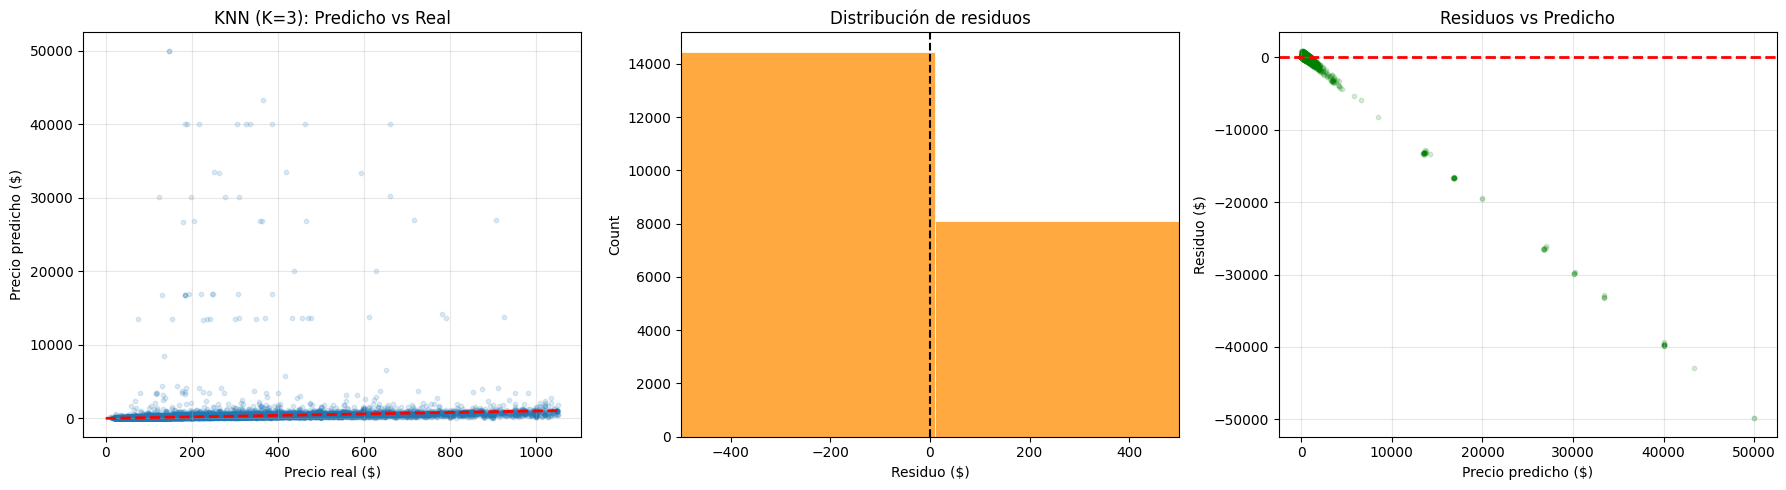

In [10]:
# Resultados en conjunto de prueba
rmse_knn = mean_squared_error(y_test_price, y_pred_knn) ** 0.5
mae_knn = mean_absolute_error(y_test_price, y_pred_knn)
r2_knn = r2_score(y_test_price, y_pred_knn)

print("=== Métricas KNN Regresión (conjunto de prueba) ===")
print(f"  RMSE: {rmse_knn:.2f}")
print(f"  MAE:  {mae_knn:.2f}")
print(f"  R²:   {r2_knn:.4f}")

# Gráficas de diagnóstico
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Predicho vs Real
limite = y_test_price.quantile(0.95)
mask = y_test_price <= limite
axes[0].scatter(y_test_price[mask], y_pred_knn[mask.values], alpha=0.15, s=10)
axes[0].plot([0, limite], [0, limite], color="red", linestyle="--", linewidth=2)
axes[0].set_xlabel("Precio real ($)")
axes[0].set_ylabel("Precio predicho ($)")
axes[0].set_title(f"KNN (K={best_k}): Predicho vs Real")
axes[0].grid(True, alpha=0.3)

# 2. Distribución de residuos
residuos = y_test_price.values - y_pred_knn
sns.histplot(residuos, bins=50, color="darkorange", edgecolor="white", ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_xlabel("Residuo ($)")
axes[1].set_title("Distribución de residuos")
axes[1].set_xlim(-500, 500)

# 3. Residuos vs predicho
axes[2].scatter(y_pred_knn[mask.values], residuos[mask.values], alpha=0.15, s=10, color="green")
axes[2].axhline(0, color="red", linestyle="--", linewidth=2)
axes[2].set_xlabel("Precio predicho ($)")
axes[2].set_ylabel("Residuo ($)")
axes[2].set_title("Residuos vs Predicho")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()